# Numerical Comparative Statics for Hagiu (2007)

Reproduction of Propositions 4, 5, and 6 of Andrei Hagiu, "Proprietary vs. Open Two-Sided Platforms and Social Efficiency," HBS Working Paper 07-095 (2006/2007).

Each section below links its numbers/figures back to the corresponding equation or proposition number / page in the paper.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.model import example1, example2
from src.equilibria import solve_equilibria, check_assumptions
from src.welfare import welfare
from src.prop4 import sweep_n_p_vs_n_fe, welfare_ratio_p_over_fe, figure_3_1_curves
from src.vertical_diff import (VerticalDiffParams, profit as vd_profit, welfare as vd_welfare,
                                solve_qm_p, solve_qm_so, sufficient_condition_holds)
from src.competition import CompetitionParams, welfare_gain, t_L, t_H, find_valid_interval

FIG_DIR = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)

## Proposition 4(i) -- both platform types under-provide variety (paper p. 21, eq. 3.4-3.6)

Both the proprietary platform (`n_p`) and the open/free-entry platform (`n_fe`) induce **less** product variety and user adoption than the social planner (`n_so`).

In [2]:
m = example1(alpha=0.2, sigma=0.4, c=1.0)
res = solve_equilibria(m, epsilon_F=1.0, epsilon_H=2.0, B=1.0, C=1.0)
print(res)
assert res.n_p < res.n_so and res.n_fe < res.n_so
assert res.theta_m_p < res.theta_m_so and res.theta_m_fe < res.theta_m_so
print('Confirmed: n_p, n_fe < n_so and theta_m_p, theta_m_fe < theta_m_so')

EquilibriumResult(n_p=0.00929053837611886, n_fe=0.008161217811322452, n_so=0.040197824942645725, theta_m_p=0.04232000000000004, theta_m_fe=0.0701084873606613, theta_m_so=0.14660078035262986)
Confirmed: n_p, n_fe < n_so and theta_m_p, theta_m_fe < theta_m_so


## Proposition 4(ii) -- the n_p vs n_fe boundary (paper p. 22)

Restricting to `epsilon_F = 1` and inelastic developer supply (`epsilon_H = inf`, common fixed cost), the paper shows:

$$n_p > n_{fe} \iff (1 - \sigma\alpha)^2 > 2\sigma(1-\alpha)^2$$

We sweep `(alpha, sigma)` and verify the numerically-solved sign of `n_p - n_fe` always matches this analytic condition.

975 valid (alpha, sigma) points checked, 0 mismatches


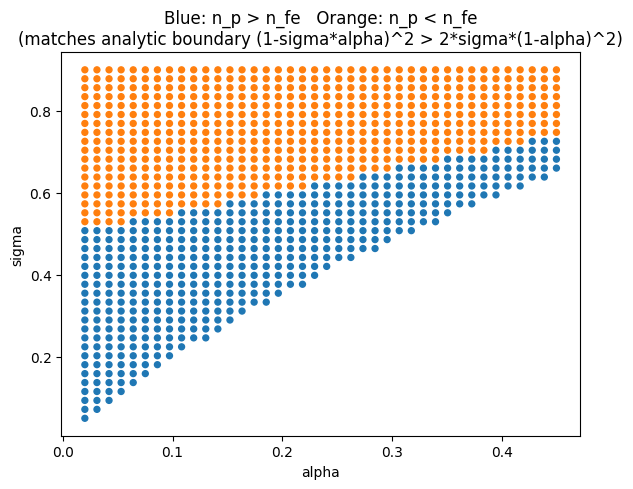

In [3]:
alphas = np.linspace(0.02, 0.45, 40)
sigmas = np.linspace(0.05, 0.9, 40)
results = sweep_n_p_vs_n_fe(list(alphas), list(sigmas))

mismatches = [r for r in results if r[2] != r[3]]
print(f'{len(results)} valid (alpha, sigma) points checked, {len(mismatches)} mismatches')

xs = [r[0] for r in results]
ys = [r[1] for r in results]
colors = ['tab:blue' if r[2] else 'tab:orange' for r in results]

plt.figure(figsize=(6, 5))
plt.scatter(xs, ys, c=colors, s=18)
plt.xlabel('alpha')
plt.ylabel('sigma')
plt.title('Blue: n_p > n_fe   Orange: n_p < n_fe\n(matches analytic boundary (1-sigma*alpha)^2 > 2*sigma*(1-alpha)^2)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'prop4_boundary.png'), dpi=150)
plt.show()

### Welfare ratio limits (paper Proposition 4.ii, second bullet)

`W(n_p)/W(n_fe) -> +inf` as `alpha, sigma -> 0` with `alpha/sigma -> k < 1/3` (stability requires `k < 1/3`), and `-> 3/4` as `sigma -> 1` (alpha fixed).

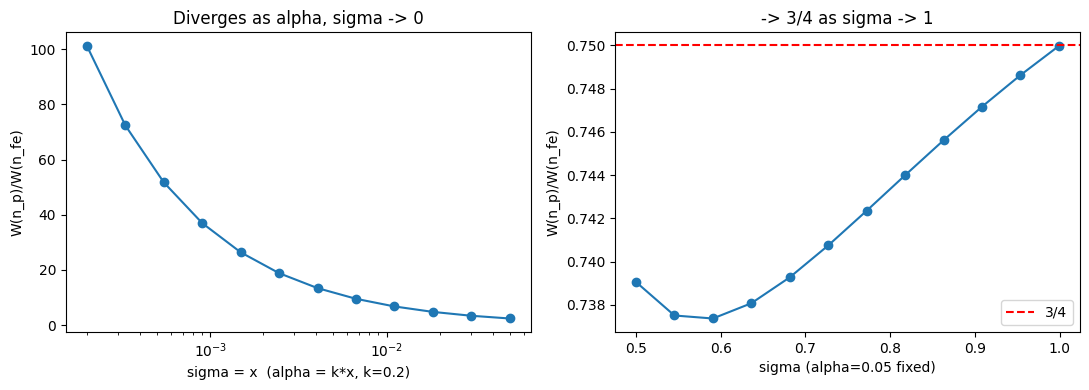

last few ratios near sigma->1: [np.float64(0.7471624788901314), np.float64(0.7486216966181096), np.float64(0.7499715644146452)]


In [4]:
k = 0.2
xs_small = np.geomspace(0.05, 0.0002, 12)
ratios_diverge = [welfare_ratio_p_over_fe(alpha=k * x, sigma=x, require_valid=False) for x in xs_small]

alpha_fixed = 0.05
sigmas_to_one = np.linspace(0.5, 0.999, 12)
ratios_to_34 = [welfare_ratio_p_over_fe(alpha=alpha_fixed, sigma=s, require_valid=False) for s in sigmas_to_one]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs_small, ratios_diverge, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('sigma = x  (alpha = k*x, k=0.2)')
axes[0].set_ylabel('W(n_p)/W(n_fe)')
axes[0].set_title('Diverges as alpha, sigma -> 0')

axes[1].plot(sigmas_to_one, ratios_to_34, marker='o')
axes[1].axhline(0.75, color='red', linestyle='--', label='3/4')
axes[1].set_xlabel('sigma (alpha=0.05 fixed)')
axes[1].set_ylabel('W(n_p)/W(n_fe)')
axes[1].set_title('-> 3/4 as sigma -> 1')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'prop4_welfare_ratio_limits.png'), dpi=150)
plt.show()

print('last few ratios near sigma->1:', ratios_to_34[-3:])

### Recreating Figure 3.1 (graphs a/b, paper p. 20)

Graph **a)**: business-stealing dominates indirect network effects (`epsilon_V*(1+epsilon_F) < 1`) -> LHS curves of (3.4)/(3.5)/(3.6) are decreasing in `n`.
Graph **b)**: indirect network effects dominate (`epsilon_V*(1+epsilon_F) > 1`) -> LHS curves are increasing in `n`.

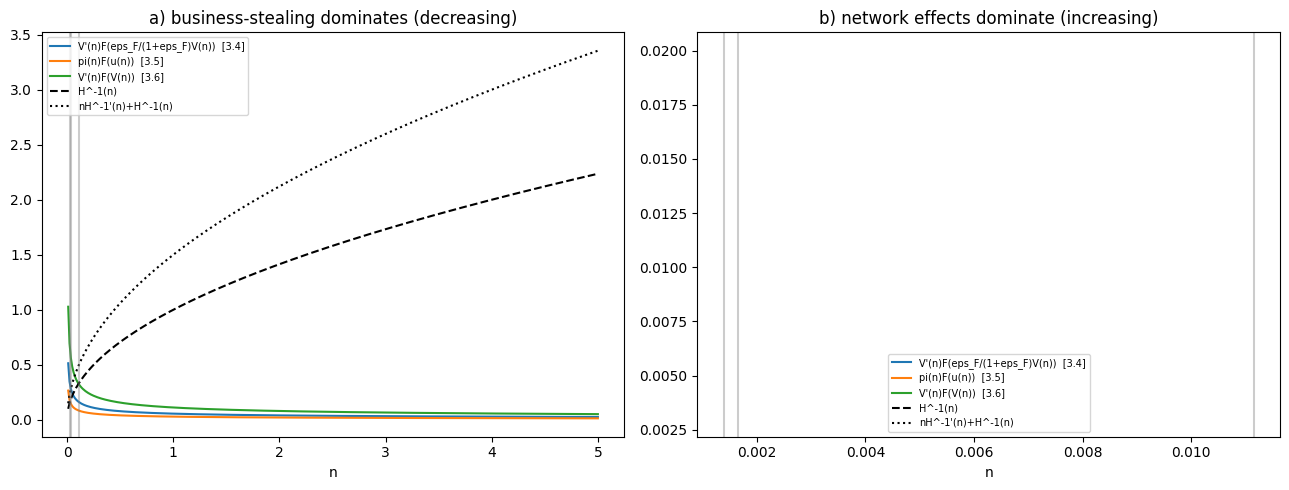

graph a: EquilibriumResult(n_p=0.03505828520666952, n_fe=0.02703235379482885, n_so=0.10737772845060287, theta_m_p=0.13780230947163702, theta_m_fe=0.239048009512088, theta_m_so=0.36839906672876865)
graph b: EquilibriumResult(n_p=0.00139348749811665, n_fe=0.001662768775266119, n_so=0.011147899984933205, theta_m_p=0.0017066666666666636, theta_m_fe=0.0028799999999999945, theta_m_so=0.013653333333333316)


In [5]:
def plot_fig31(ax, alpha, sigma, epsilon_F, epsilon_H, n_max, title):
    m = example1(alpha=alpha, sigma=sigma, c=1.0)
    res = solve_equilibria(m, epsilon_F=epsilon_F, epsilon_H=epsilon_H)
    n_grid = np.linspace(0.01, n_max, 400)
    curves = figure_3_1_curves(m, n_grid, epsilon_F, epsilon_H)
    ax.plot(curves['n'], curves['proprietary_lhs'], label="V'(n)F(eps_F/(1+eps_F)V(n))  [3.4]")
    ax.plot(curves['n'], curves['open_lhs'], label='pi(n)F(u(n))  [3.5]')
    ax.plot(curves['n'], curves['social_lhs'], label="V'(n)F(V(n))  [3.6]")
    ax.plot(curves['n'], curves['H_inv'], 'k--', label='H^-1(n)')
    ax.plot(curves['n'], curves['nH_inv_prime_plus_H_inv'], 'k:', label="nH^-1'(n)+H^-1(n)")
    for n_val, lbl in [(res.n_p, 'n_p'), (res.n_fe, 'n_fe'), (res.n_so, 'n_so')]:
        ax.axvline(n_val, color='gray', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('n')
    ax.legend(fontsize=7)
    return res

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
res_a = plot_fig31(axes[0], alpha=0.1, sigma=0.3, epsilon_F=1.0, epsilon_H=2.0, n_max=5,
                    title='a) business-stealing dominates (decreasing)')
res_b = plot_fig31(axes[1], alpha=0.4, sigma=0.5, epsilon_F=1.0, epsilon_H=1.0, n_max=0.01,
                    title='b) network effects dominate (increasing)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'prop4_figure_3_1.png'), dpi=150)
plt.show()

print('graph a:', res_a)
print('graph b:', res_b)

## Proposition 5 -- vertical differentiation can induce *excessive* variety (paper p. 26)

With developers vertically differentiated by quality and a common fixed cost, if `beta*qL > 2*qH` then `Pi_P(qm)` and `W(qm)` are both concave, and the profit-maximizing quality threshold `qm_p` is **below** the socially optimal `qm_so` -- i.e. the proprietary platform admits *more* developers than is socially optimal (the opposite of the horizontal-differentiation result above).

sufficient condition beta*qL > 2*qH holds: True
qm_p = 1.0275272654321959  qm_so = 1.150202226923005  qm_p < qm_so: True


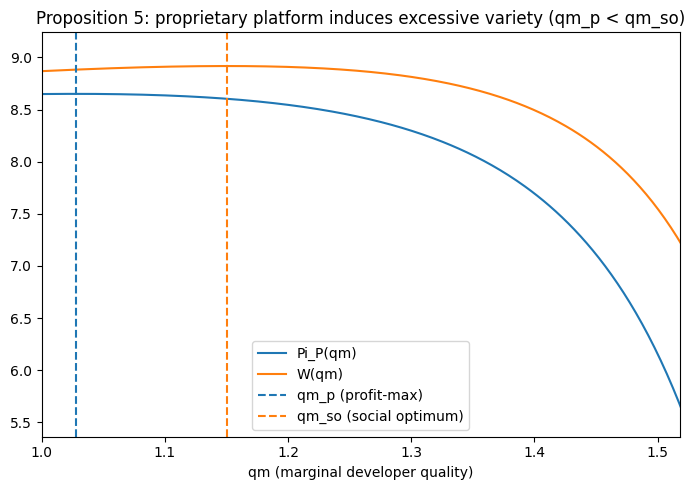

In [6]:
vp = VerticalDiffParams(qL=1.0, qH=2.0, C=1.0, B=1.0, Vbar=10.0, A=1.0, beta=5.0, phi=1.0)
print('sufficient condition beta*qL > 2*qH holds:', sufficient_condition_holds(vp))

qm_p = solve_qm_p(vp)
qm_so = solve_qm_so(vp)
print('qm_p =', qm_p, ' qm_so =', qm_so, ' qm_p < qm_so:', qm_p < qm_so)

qs = np.linspace(vp.qL + 1e-4, vp.qH - 1e-4, 600)
profits = [vd_profit(q, vp) for q in qs]
welfares = [vd_welfare(q, vp) for q in qs]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(qs, profits, label='Pi_P(qm)')
ax.plot(qs, welfares, label='W(qm)')
ax.axvline(qm_p, color='tab:blue', linestyle='--', label='qm_p (profit-max)')
ax.axvline(qm_so, color='tab:orange', linestyle='--', label='qm_so (social optimum)')
# zoom in near the interior optima; V(Q) -> -inf as qm -> qH (Q -> 0) otherwise
# dwarfs the interesting region on both axes
zoom_max = qm_so + 3 * (qm_so - qm_p)
ax.set_xlim(vp.qL, zoom_max)
visible = [v for q, v in zip(qs, welfares) if q < zoom_max] + \
          [v for q, v in zip(qs, profits) if q < zoom_max]
pad = 0.1 * (max(visible) - min(visible))
ax.set_ylim(min(visible) - pad, max(visible) + pad)
ax.set_xlabel('qm (marginal developer quality)')
ax.set_title('Proposition 5: proprietary platform induces excessive variety (qm_p < qm_so)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'prop5_excessive_variety.png'), dpi=150)
plt.show()

## Proposition 6 -- monopoly platform can beat platform competition (paper p. 29-30, 41-42)

With a Hotelling extension (users single-home, developers multihome, common fixed cost), there is a non-empty interval `[t_L, t_H]` of transport costs for which total social welfare is **higher** under a single monopoly platform than under two competing platforms -- because competition prevents platforms from internalizing positive indirect network effects enough to induce sufficient product variety.

[t_L, t_H] = [3.3333, 6.6667]  (non-empty: True)


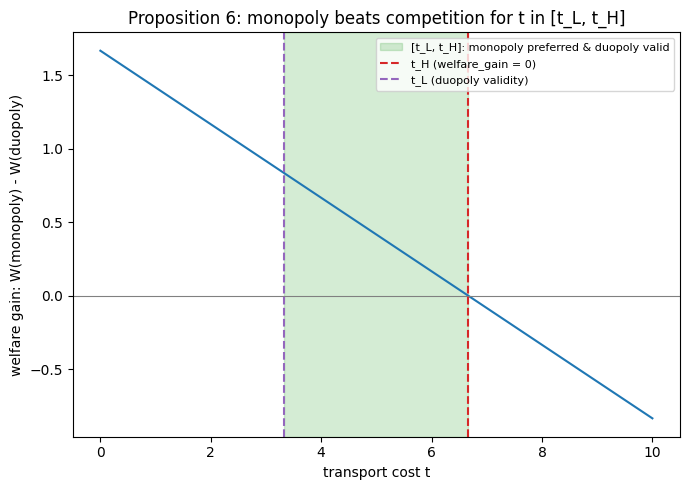

In [7]:
cp = CompetitionParams(A=2.0, beta=0.5, phi=0.3)
lo, hi = find_valid_interval(cp)
print(f'[t_L, t_H] = [{lo:.4f}, {hi:.4f}]  (non-empty: {lo <= hi})')

ts = np.linspace(0, hi * 1.5, 200)
gains = [welfare_gain(t, cp) for t in ts]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts, gains)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvspan(lo, hi, color='tab:green', alpha=0.2, label='[t_L, t_H]: monopoly preferred & duopoly valid')
ax.axvline(hi, color='tab:red', linestyle='--', label='t_H (welfare_gain = 0)')
ax.axvline(lo, color='tab:purple', linestyle='--', label='t_L (duopoly validity)')
ax.set_xlabel('transport cost t')
ax.set_ylabel('welfare gain: W(monopoly) - W(duopoly)')
ax.set_title('Proposition 6: monopoly beats competition for t in [t_L, t_H]')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'prop6_interval.png'), dpi=150)
plt.show()